In [1]:
import os
from pathlib import Path

PROJECT_DIR = Path(os.getenv('PROJECT_DIR'))
os.makedirs(PROJECT_DIR / 'paper/figures/subject_leakage', exist_ok=True)

In [2]:
import mlflow
client = mlflow.tracking.MlflowClient()

all_runs = mlflow.search_runs(search_all_experiments=True)
df_filter = (all_runs['status'] == 'FAILED') & (all_runs['params.pretrained'] == 'True')
all_runs = all_runs[~df_filter]

In [3]:
experiment_id_map = {e.experiment_id: e.name for e in mlflow.search_experiments()}

In [4]:
all_runs['experiment_name'] = all_runs['experiment_id'].apply(lambda x: experiment_id_map[x])
all_runs['params.model_name'] = all_runs['params.model_name'].apply(lambda x: x.replace('resnet', 'ResNet ') if 'resnet' in x else 'EfficientNet B0')

# infer subject leakage from experiment name
all_runs['subject_leakage'] = all_runs['experiment_name'].apply(lambda x: x.split()[0].split('=')[-1] == 'True')

### Learning curves

In [5]:
def get_metric_history(run_id, metric, metric_name):
    metrics = client.get_metric_history(run_id, metric)

    x = [m.step + 1 for m in metrics]
    y = [m.value for m in metrics]
    return pd.DataFrame({'Epoch': x, metric_name: y})

In [6]:
metric_map = {
    'train_mae_epoch': 'Train MAE',
    'val_mae_epoch': 'Val. MAE',
    'train_r2_epoch': 'Train R²',
    'val_r2_epoch': 'Val. R²',
}

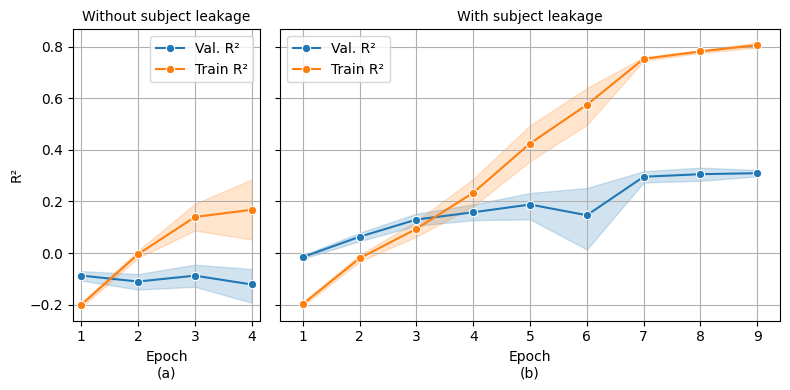

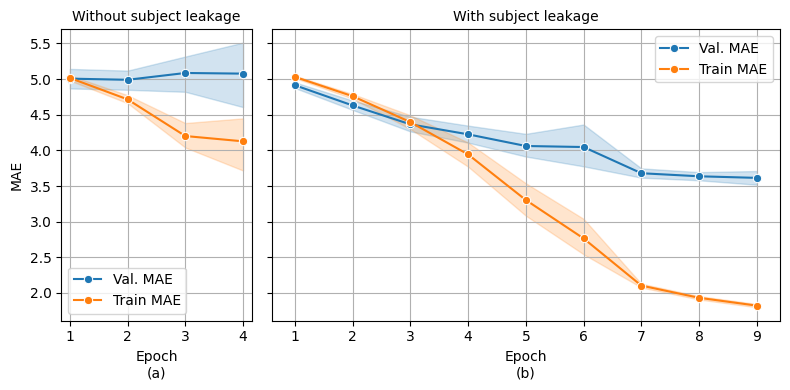

In [7]:
import math

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import pandas as pd

epoch_cutoff = math.inf
label = 'Epoch'

for i, (pair, metric_name) in enumerate([
    (['val_r2_epoch', 'train_r2_epoch'], 'R²'),
    (['val_mae_epoch', 'train_mae_epoch'], 'MAE'),
]):
    fig = plt.figure(figsize=(8, 4))

    # infer number of epochs
    max_epoch_left = 0
    for metric in pair:       
        metrics = pd.DataFrame()
        for run_id in all_runs[~all_runs['subject_leakage']]['run_id'].to_list():
            new_metrics = get_metric_history(run_id, metric, metric_map[metric])
            metrics = pd.concat([metrics, new_metrics])

        epoch_left = max(metrics[metrics['Epoch'] <= epoch_cutoff]['Epoch']) - 1
        if epoch_left > max_epoch_left:
            max_epoch_left = epoch_left
    max_epoch_right = 0
    for metric in pair:       
        metrics = pd.DataFrame()
        for run_id in all_runs[all_runs['subject_leakage']]['run_id'].to_list():
            new_metrics = get_metric_history(run_id, metric, metric_map[metric])
            metrics = pd.concat([metrics, new_metrics])
        epoch_right = max(metrics[metrics['Epoch'] <= epoch_cutoff]['Epoch']) - 1
        if epoch_right > max_epoch_right:
            max_epoch_right = epoch_right

    # space proportional to the number of epochs
    widths = [max_epoch_left / (max_epoch_left + max_epoch_right),
              max_epoch_right / (max_epoch_left + max_epoch_right)]
    gs = gridspec.GridSpec(1, 2, width_ratios=widths)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharey=ax1)

    # on the left without leakage
    for metric in pair:       
        metrics = pd.DataFrame()
        for run_id in all_runs[~all_runs['subject_leakage']]['run_id'].to_list():
            new_metrics = get_metric_history(run_id, metric, metric_map[metric])
            metrics = pd.concat([metrics, new_metrics])

        sns.lineplot(
            data=metrics[metrics['Epoch'] <= epoch_cutoff],
            x='Epoch',
            y=metric_map[metric],
            marker='o',
            label=metric_map[metric],
            ax=ax1
        )

    # on the right with leakage
    for metric in pair:       
        metrics = pd.DataFrame()
        for run_id in all_runs[all_runs['subject_leakage']]['run_id'].to_list():
            new_metrics = get_metric_history(run_id, metric, metric_map[metric])
            metrics = pd.concat([metrics, new_metrics])

        sns.lineplot(
            data=metrics[metrics['Epoch'] <= epoch_cutoff],
            x='Epoch',
            y=metric_map[metric],
            marker='o',
            label=metric_map[metric],
            ax=ax2
        )

    # customize left plot
    ax1.grid()
    ax1.set_ylabel(metric_name)
    ax1.set_xlabel(f'{label}\n(a)')
    ax1.set_title('Without subject leakage', fontsize=10)
    ax1.xaxis.set_major_locator(MultipleLocator(1))

    # customize right plot
    ax2.grid()
    ax2.set_xlabel(f'{label}\n(b)')
    ax2.set_ylabel(None)
    ax2.set_title('With subject leakage', fontsize=10)
    ax2.xaxis.set_major_locator(MultipleLocator(1))
    plt.setp(ax2.get_yticklabels(), visible=False)

    plt.tight_layout()
    plt.savefig(PROJECT_DIR / f'paper/figures/subject_leakage/0{i+2}-{pair[0].split("_")[1]}-curve.pdf', bbox_inches='tight')
    plt.show()